# Notebook 2 — Feature Engineering

This notebook builds the feature representations used for classification.

**Three feature families:**
1. **TF-IDF** - term-frequency inverse document frequency, sparse high-dimensional representation
2. **LSA (Latent Semantic Analysis)** - TF-IDF reduced to 150 dense dimensions via SVD
3. **Structural features** - 8 normalized HTML structural signals

**Outputs:**
- Fitted vectorizer, SVD transformer
- 2D SVD projection for scatter visualisation
- Feature matrices for modeling notebook

## 1. Imports

In [23]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

DATA_DIR   = '../data'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

CLASSES = ['FAQ','accueil','blog','commerce','home','liste','recherche']
PALETTE = ['#7c6aff','#ff6a9e','#6affd4','#ffd06a','#ff9d6a','#6ab8ff','#d46aff']

plt.rcParams.update({
    # Backgrounds
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',

    # Fonts and Text
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': '#333333',
    'axes.labelcolor': '#333333',

    # Axes and Spines
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,

    # Ticks
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'xtick.bottom': True,
    'ytick.left': False,

    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#eeeeee',
    'grid.linestyle': '-',
    'grid.linewidth': 0.8,
})

## 2. Load Processed Data

We load the parquet files saved by Notebook 01.

In [5]:
train_txt = pd.read_parquet(f'{DATA_DIR}/train_texts.parquet')
test_txt  = pd.read_parquet(f'{DATA_DIR}/test_texts.parquet')
train_csv = pd.read_csv(f'{DATA_DIR}/train_features.csv')
test_csv  = pd.read_csv(f'{DATA_DIR}/test_features.csv')

train_df = train_csv.merge(train_txt[['file','text']], on='file')
test_df  = test_csv.merge(test_txt[['file','text']],   on='file')

In [7]:
STRUCT_COLS = ['n_links','n_forms','n_inputs','n_tables','n_imgs','n_headings','n_list_items','text_len']

le = LabelEncoder()
le.fit(CLASSES)
y_train = le.transform(train_df['label'])
y_test  = le.transform(test_df['label'])

print(f'Train: {len(train_df)} | Test: {len(test_df)}')
train_df[['label','text_len'] + STRUCT_COLS[:4]].head(3)

Train: 840 | Test: 210


,label,text_len,n_links,n_forms,n_inputs,n_tables
0,FAQ,2383,31,1,4,5
1,FAQ,3202,32,1,4,5
2,FAQ,5493,32,1,4,5


## 3. TF-IDF Representation

**Parameters chosen:**
- `max_features=10000` - vocabulary cap
- `sublinear_tf=True` - log(1+tf) dampens high-frequency terms
- `ngram_range=(1,2)` - bigrams capture phrases like 'search results', 'add to cart'
- `stop_words='english'` - removes uninformative tokens

In [8]:
tfidf = TfidfVectorizer(
    max_features=10000,
    sublinear_tf=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(train_df['text'])
X_test_tfidf  = tfidf.transform(test_df['text'])

print(f'TF-IDF train matrix: {X_train_tfidf.shape}')
print(f'TF-IDF test  matrix: {X_test_tfidf.shape}')
print(f'Sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.3%}')

TF-IDF train matrix: (840, 10000)
TF-IDF test  matrix: (210, 10000)
Sparsity: 97.168%


### TF-IDF Vocabulary Analysis

Vocabulary: 10000 terms (6839 unigrams, 3161 bigrams)


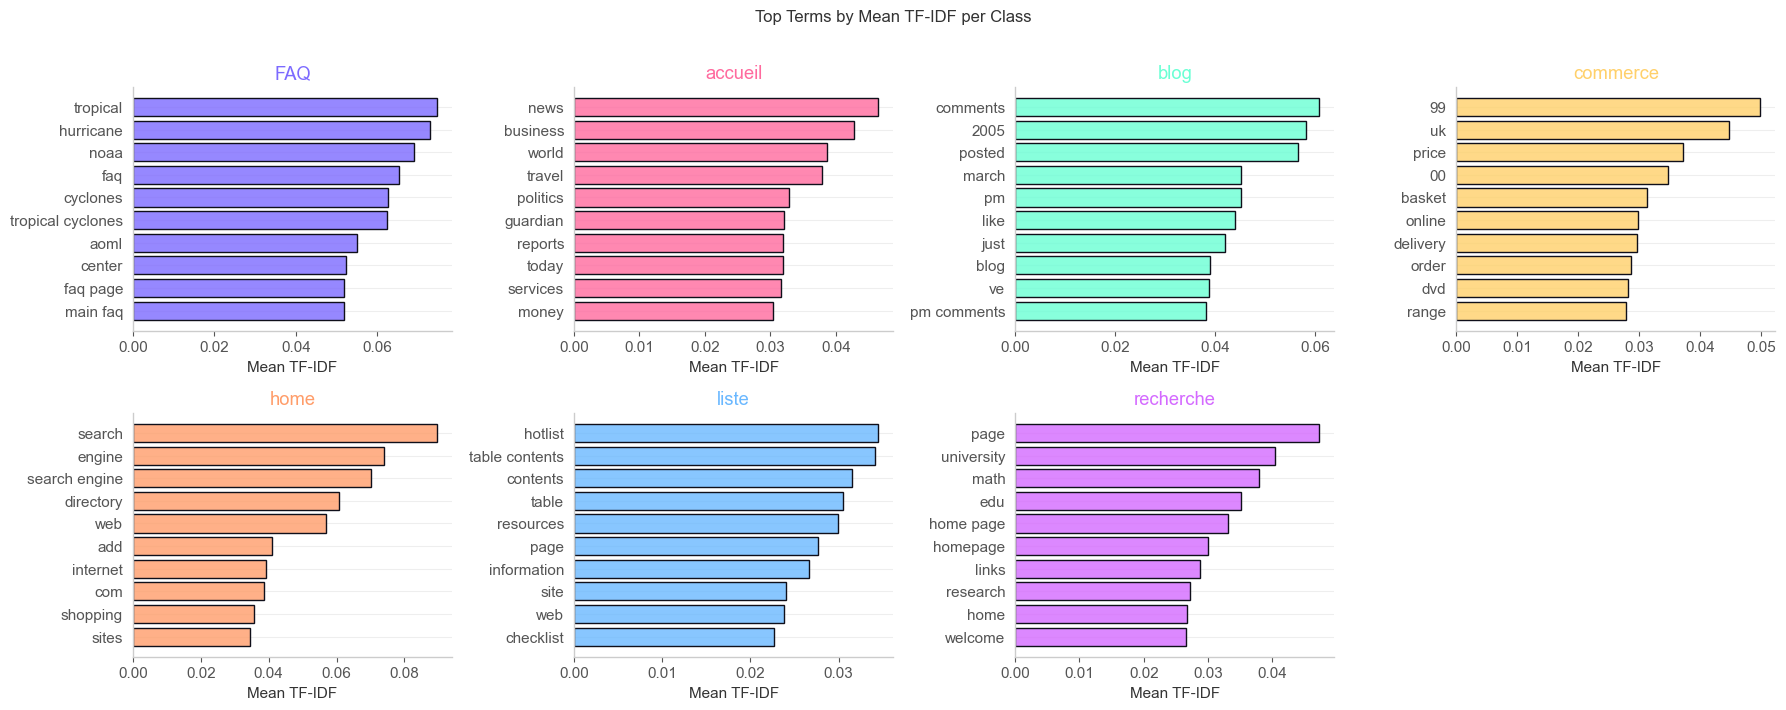

In [12]:
vocab_words = tfidf.get_feature_names_out()
n_unigrams = sum(1 for w in vocab_words if ' ' not in w)
n_bigrams  = len(vocab_words) - n_unigrams
print(f'Vocabulary: {len(vocab_words)} terms ({n_unigrams} unigrams, {n_bigrams} bigrams)')

# Mean TF-IDF per class (top discriminative terms)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, (cls, color) in enumerate(zip(CLASSES, PALETTE)):
    idx = np.where(le.transform(train_df['label']) == le.transform([cls])[0])[0]
    class_tfidf = X_train_tfidf[idx].mean(axis=0).A1
    top = class_tfidf.argsort()[::-1][:10]
    axes[i].barh([vocab_words[j] for j in top][::-1], class_tfidf[top][::-1], color=color+'cc', edgecolor='#0f0f1a')
    axes[i].set_title(f'{cls}', color=color)
    axes[i].set_xlabel('Mean TF-IDF')
axes[-1].set_visible(False)
plt.suptitle('Top Terms by Mean TF-IDF per Class', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feat_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. LSA (Latent Semantic Analysis) via Truncated SVD

SVD decomposes the TF-IDF matrix into latent semantic dimensions. This:
- Reduces dimensionality from 10k to 150
- Captures synonymy and co-occurrence patterns
- Produces dense vectors required by KNN's cosine distance

LSA 150 components explain 47.3% of total variance


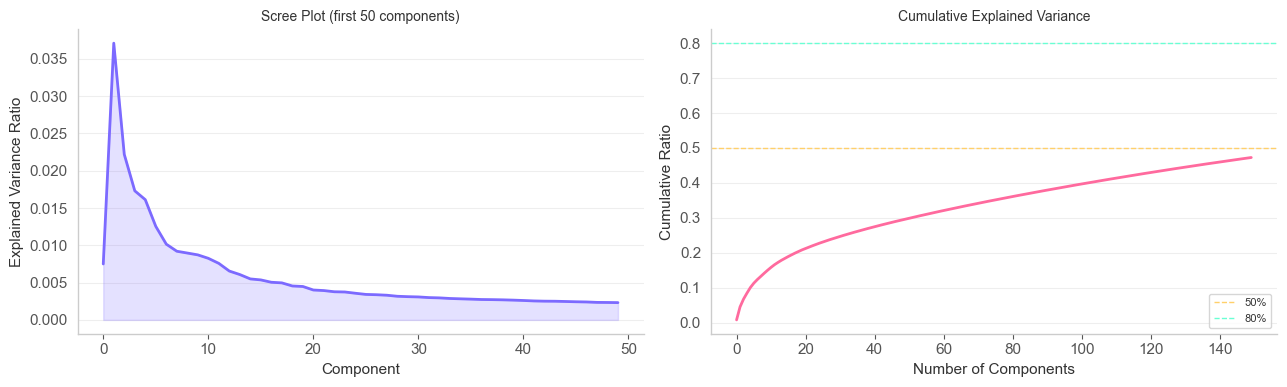

In [13]:
svd = TruncatedSVD(n_components=150, random_state=42)
X_train_svd = normalize(svd.fit_transform(X_train_tfidf))
X_test_svd  = normalize(svd.transform(X_test_tfidf))

explained = svd.explained_variance_ratio_.cumsum()
print(f'LSA 150 components explain {explained[-1]:.1%} of total variance')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(svd.explained_variance_ratio_[:50], color='#7c6aff', linewidth=2)
axes[0].fill_between(range(50), svd.explained_variance_ratio_[:50], alpha=0.2, color='#7c6aff')
axes[0].set_title('Scree Plot (first 50 components)', fontsize=10)
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(explained, color='#ff6a9e', linewidth=2)
axes[1].axhline(0.5, color='#ffd06a', linestyle='--', linewidth=1, label='50%')
axes[1].axhline(0.8, color='#6affd4', linestyle='--', linewidth=1, label='80%')
axes[1].set_title('Cumulative Explained Variance', fontsize=10)
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Ratio')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feat_svd_scree.png', dpi=150, bbox_inches='tight')
plt.show()

### 2D SVD Projection (Class Separation)

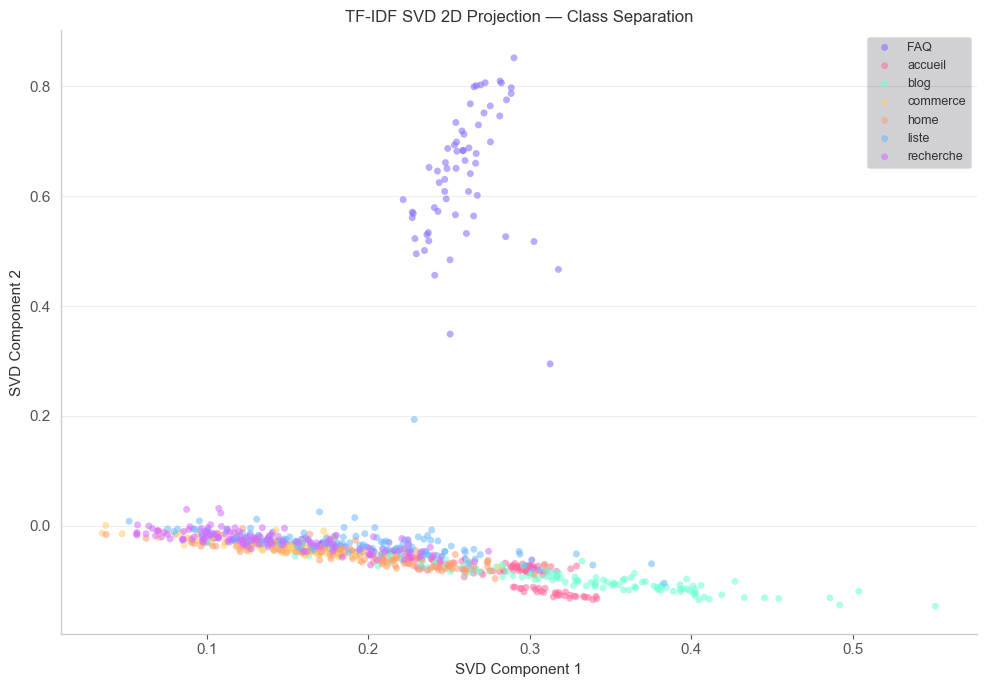

In [14]:
svd2 = TruncatedSVD(n_components=2, random_state=42)
X2d = svd2.fit_transform(X_train_tfidf)

fig, ax = plt.subplots(figsize=(10, 7))
for i, (cls, color) in enumerate(zip(CLASSES, PALETTE)):
    mask = train_df['label'] == cls
    ax.scatter(X2d[mask, 0], X2d[mask, 1],
               c=color, alpha=0.55, s=25, label=cls, edgecolors='none')

ax.set_title('TF-IDF SVD 2D Projection — Class Separation', fontsize=12)
ax.set_xlabel('SVD Component 1'); ax.set_ylabel('SVD Component 2')
ax.legend(fontsize=9, framealpha=0.2, facecolor='#1a1a2e')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feat_svd_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Structural Features

We normalize structural features by dividing by 100 to bring them into comparable scale with the SVD components.

In [19]:
scaler = StandardScaler()

X_train_struct = scaler.fit_transform(train_df[STRUCT_COLS])
X_test_struct  = scaler.transform(test_df[STRUCT_COLS])

# Combined feature matrix for KNN
X_train_knn = np.hstack([X_train_svd, X_train_struct])
X_test_knn  = np.hstack([X_test_svd,  X_test_struct])
print(f'KNN feature matrix: {X_train_knn.shape}  (150 LSA + 8 structural)')
print(f'SVM feature matrix: {X_train_tfidf.shape} (sparse TF-IDF)')

KNN feature matrix: (840, 158)  (150 LSA + 8 structural)
SVM feature matrix: (840, 10000) (sparse TF-IDF)


### Structural Feature Distributions

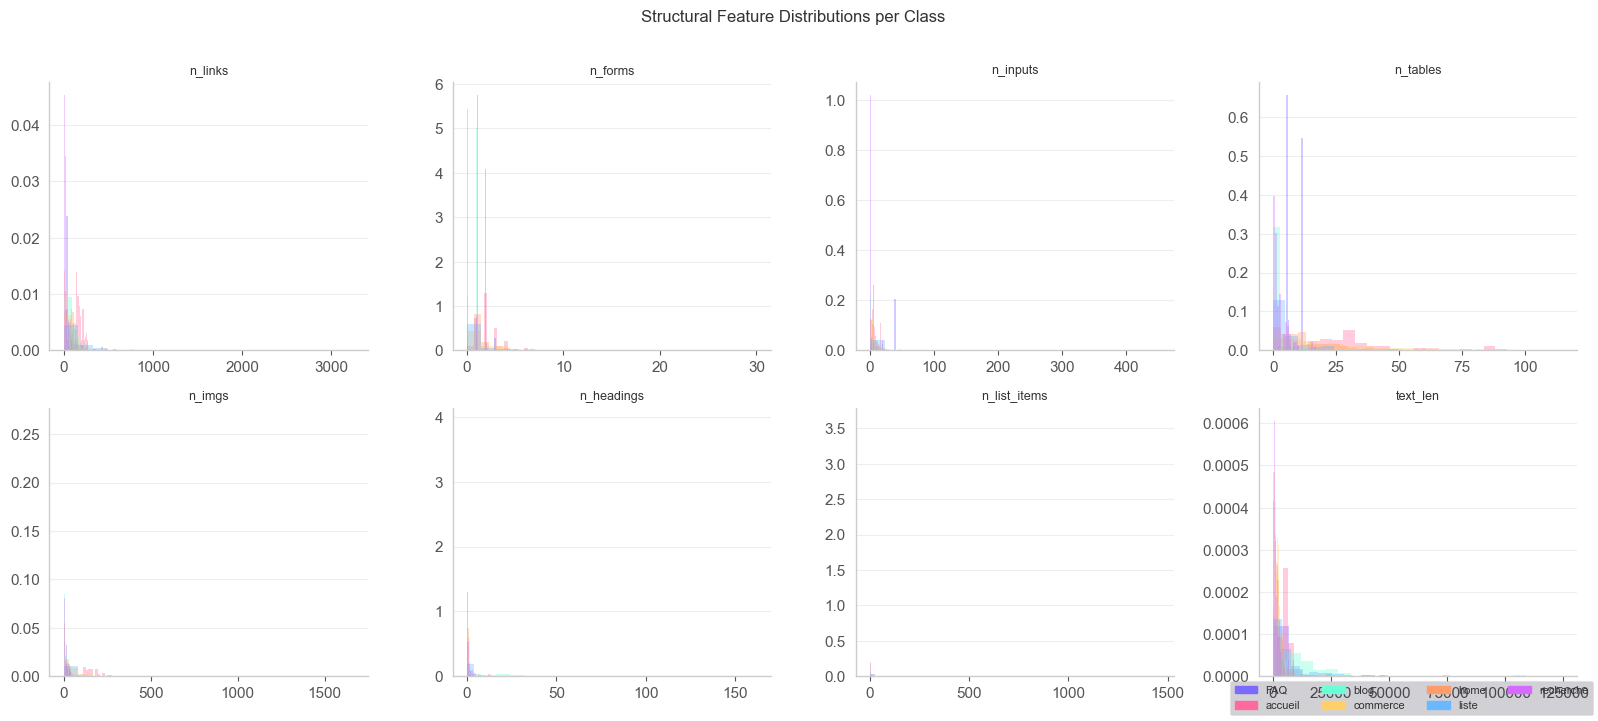

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(STRUCT_COLS):
    for cls, color in zip(CLASSES, PALETTE):
        vals = train_df[train_df['label']==cls][col].values
        axes[i].hist(vals, bins=20, color=color, alpha=0.35, edgecolor='none', density=True)
    axes[i].set_title(col, fontsize=9)

patches = [mpatches.Patch(color=PALETTE[i], label=CLASSES[i]) for i in range(len(CLASSES))]
fig.legend(handles=patches, loc='lower right', ncol=4, fontsize=8, framealpha=0.2, facecolor='#1a1a2e')

plt.suptitle('Structural Feature Distributions per Class', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feat_struct_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Feature Matrices & Transformers

In [31]:
# Save transformers
with open(f'{MODELS_DIR}/tfidf.pkl', 'wb') as f: pickle.dump(tfidf, f)
with open(f'{MODELS_DIR}/svd150.pkl', 'wb') as f: pickle.dump(svd, f)
with open(f'{MODELS_DIR}/label_encoder.pkl', 'wb') as f: pickle.dump(le, f)
with open(f'{MODELS_DIR}/standard_scaler.pkl', 'wb') as f: pickle.dump(scaler, f)

# # Save dense arrays
# np.save(f'{DATA_DIR}/X_train_knn.npy', X_train_knn)
# np.save(f'{DATA_DIR}/X_test_knn.npy',  X_test_knn)
# np.save(f'{DATA_DIR}/y_train.npy', y_train)
# np.save(f'{DATA_DIR}/y_test.npy',  y_test)

# # Save sparse TF-IDF
# from scipy.sparse import save_npz
# save_npz(f'{DATA_DIR}/X_train_tfidf.npz', X_train_tfidf)
# save_npz(f'{DATA_DIR}/X_test_tfidf.npz',  X_test_tfidf)

print('Saved all transformers and feature matrices.')
print(f'  tfidf.pkl, svd150.pkl, label_encoder.pkl, standard_scaler.pkl')
# print(f'  X_train_knn.npy ({X_train_knn.shape})')
# print(f'  X_train_tfidf.npz ({X_train_tfidf.shape})')

Saved all transformers and feature matrices.
  tfidf.pkl, svd150.pkl, label_encoder.pkl, standard_scaler.pkl
  X_train_knn.npy ((840, 158))
  X_train_tfidf.npz ((840, 10000))


## Summary

| Feature Set | Shape | Model Target |
|---|---|---|
| TF-IDF (sparse) | (840, 10000) | SVM (LinearSVC) |
| LSA + Structural (dense) | (840, 158) | KNN (cosine) |
| Label-encoded targets | (840,) | Both |

**Next step:** Notebook 03 - Model Training, Evaluation & Results